# Craft a Story from a Dataset

This notebook is for the "Craft a Story from a Dataset" Springboard assignment.

We take a clean dataset, ask a question, and create a presentation that displays an answer. If there are opportunities for continued exploration, we may pose those questions at the conclusion.

## Key Question

This Jupyter Notebook presentation asks the question, 'How has GDP changed in relation to population change?'

# Library Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Importing the Data

Our goal here is to compare the population of England to the GDP. We will look at the time period of `1270` to `1700`, as that's the data that is readily available. 

In [2]:
filename = 'a-millennium-of-macroeconomic-data-for-the-uk.xlsx'

In [3]:
excel_file = pd.ExcelFile(filename)

In [4]:
excel_file.sheet_names

['Disclaimer',
 'Corrections to V3.1',
 'Front page',
 'A1. Headline series',
 'BEG Table of contents',
 'A2. Pop of Eng & GB 1086-1870',
 'A3. Eng. Agriculture 1270-1870',
 'A4. Ind Production 1270-1870',
 'A5. Service Sector 1270-1870',
 'A6. English GDP(O) 1270-1700',
 'A7. GB GDP(O) 1700-1870',
 'Notes on GDP estimates',
 'A8. UK Real GDP(A)',
 'A9. Nominal GDP (A)',
 'A10. GNP and National Saving',
 'A11. GDP(E) components - values',
 'A12. GDP(E) components - vols',
 'A13. GDP(E) contributions',
 'A14. Real GDP(O) components',
 'A15. Factor incomes by SIC ',
 'A16. Industry GVA shares by SIC',
 'A17. GDP(I) components',
 'A18. Population 1680+',
 'A19a. UK Migration flows',
 'A19b. GB and Irish Migration',
 'A19c. English Net Migration',
 'A20. Migration by citizenship',
 'A21. GDP per capita 1086+',
 'A22. Coin in circulation',
 "A23. Bank of England B'Sheet",
 'A24. Monetary aggregates',
 'A25. Credit aggregates',
 'A25a. Bills of Exchange',
 'A26. Central govt 1290-1689',
 'A2

In [5]:
pop_sheet_name = 'A2. Pop of Eng & GB 1086-1870'
df_pop = pd.read_excel(filename, sheet_name=pop_sheet_name)

In [6]:
gdp_sheet_name = 'A6. English GDP(O) 1270-1700'
df_gdp = pd.read_excel(filename, sheet_name=gdp_sheet_name)

## Inspecting the Data

### Population Data

In [7]:
df_pop.head()

,Back to front page,A2. Population of England and Great Britain 1086-1870,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,For a summary overview of the methodology and ...,NaN
2,NaN,"Broadberry, Stephen, Bruce M.S. Campbell, Ale...",NaN
3,NaN,http://www.cambridge.org/gb/academic/subjects/...,NaN
4,NaN,"When using this data, please cite this source.",NaN


In [8]:
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 3 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   Back to front page                                     786 non-null    object
 1   A2. Population of England and Great Britain 1086-1870  790 non-null    object
 2   Unnamed: 2                                             172 non-null    object
dtypes: object(3)
memory usage: 18.7+ KB


In [9]:
df_pop.nunique()

Back to front page                                       786
A2. Population of England and Great Britain 1086-1870    790
Unnamed: 2                                               172
dtype: int64

In [10]:
df_pop.describe()

,Back to front page,A2. Population of England and Great Britain 1086-1870,Unnamed: 2
count,786,790,172
unique,786,790,172
top,Year,For a summary overview of the methodology and ...,"Population of Great Britain, millions"
freq,1,1,1


It looks like the columns need to be renamed.

In [11]:
df_pop.head(10)

,Back to front page,A2. Population of England and Great Britain 1086-1870,Unnamed: 2
0,NaN,NaN,NaN
1,NaN,For a summary overview of the methodology and ...,NaN
2,NaN,"Broadberry, Stephen, Bruce M.S. Campbell, Ale...",NaN
3,NaN,http://www.cambridge.org/gb/academic/subjects/...,NaN
4,NaN,"When using this data, please cite this source.",NaN
5,NaN,NaN,NaN
6,Year,"Population of England, millions","Population of Great Britain, millions"
7,1086,1.71,NaN
8,1087,1.71981,NaN
9,1088,1.729676,NaN


We can see there's a request to cite the source for this data. Let's list it here before dropping the data.

In [12]:
df_pop.iloc[3,1]

'http://www.cambridge.org/gb/academic/subjects/history/economic-history/british-economic-growth-12701870?format=PB'

In [13]:
df_pop.columns = df_pop.iloc[6]

In [14]:
df_pop = df_pop.iloc[7:,:]

In [15]:
df_pop.head()

6,Year,"Population of England, millions","Population of Great Britain, millions"
7,1086,1.71,NaN
8,1087,1.71981,NaN
9,1088,1.729676,NaN
10,1089,1.739598,NaN
11,1090,1.749578,NaN


We're just looking for data for England, not Great Britain (which would include Scotland and Wales).

In [16]:
df_pop = df_pop.iloc[:,:2]

In [17]:
df_pop.head()

6,Year,"Population of England, millions"
7,1086,1.71
8,1087,1.71981
9,1088,1.729676
10,1089,1.739598
11,1090,1.749578


We want the years `1270` to `1700`.

In [18]:
df_pop = df_pop.reset_index(drop=True)

In [19]:
index_start = df_pop.index[df_pop['Year'] == 1270].tolist()

In [20]:
index_end = df_pop.index[df_pop['Year'] == 1700].tolist()

In [21]:
index_start[0]

184

In [22]:
index_end

[614]

In [23]:
df_pop.iloc[index_start[0]]

6
Year                                   1270
Population of England, millions    4.364903
Name: 184, dtype: object

In [24]:
df_pop.iloc[index_end[0]]

6
Year                                   1700
Population of England, millions    5.195805
Name: 614, dtype: object

In [25]:
df_pop = df_pop.iloc[index_start[0]:index_end[0] + 1, :]

In [26]:
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 184 to 614
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Year                             431 non-null    object
 1   Population of England, millions  431 non-null    object
dtypes: object(2)
memory usage: 6.9+ KB


In [27]:
df_pop.nunique()

6
Year                               431
Population of England, millions    431
dtype: int64

### GDP Data

In [28]:
df_gdp.head(10)

,Unnamed: 0,A6. English GDP(O) 1086-1700,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Back to front page,For a summary overview of the methodology and ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,"Broadberry, Stephen, Bruce M.S. Campbell, Ale...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,http://www.cambridge.org/gb/academic/subjects/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,"When using this data, please cite this source.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Year,Real GDP (1700 =100),NaN,NaN,NaN,NaN,Nominal GDP (mn £),NaN,Price Index (1700=100),NaN,NaN,NaN
6,NaN,Agriculture,Industry,Services,GDP,NaN,NaN,NaN,Agriculture,Industry,Services,GDP Deflator
7,1086 (Walker (2008)),NaN,NaN,NaN,NaN,NaN,0.386-0.4745,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1270,64.596764,28.151841,37.005158,40.581988,NaN,4.440546,NaN,17.789079,15.346818,16.687132,16.597583


From the lists above, we are looking for the `Year` and the `Nominal GDP` columns. Everything else can go.

In [29]:
df_gdp.columns = df_gdp.iloc[5]

In [30]:
df_gdp = df_gdp.iloc[9:, [0, 6]]

In [31]:
df_gdp.head()

5,Year,Nominal GDP (mn £)
9,1270,4.440546
10,1271,4.7903
11,1272,4.963715
12,1273,4.421184
13,1274,4.691772


In [32]:
df_gdp.tail()

5,Year,Nominal GDP (mn £)
435,1696,64.545032
436,1697,66.528233
437,1698,70.110125
438,1699,63.396924
439,1700,65.926226


In [33]:
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 9 to 439
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                431 non-null    object
 1   Nominal GDP (mn £)  431 non-null    object
dtypes: object(2)
memory usage: 6.9+ KB


## Joining the Datasets

In [34]:
df = pd.merge(df_pop, df_gdp, left_on='Year', right_on='Year')

In [35]:
df.head()

,Year,"Population of England, millions",Nominal GDP (mn £)
0,1270,4.364903,4.440546
1,1271,4.371751,4.7903
2,1272,4.378609,4.963715
3,1273,4.385478,4.421184
4,1274,4.392357,4.691772


In [36]:
df.tail()

,Year,"Population of England, millions",Nominal GDP (mn £)
426,1696,5.118433,64.545032
427,1697,5.150015,66.528233
428,1698,5.177316,70.110125
429,1699,5.190149,63.396924
430,1700,5.195805,65.926226


# Visualizing the Data

We would like to see how GDP has changed in relation to population.

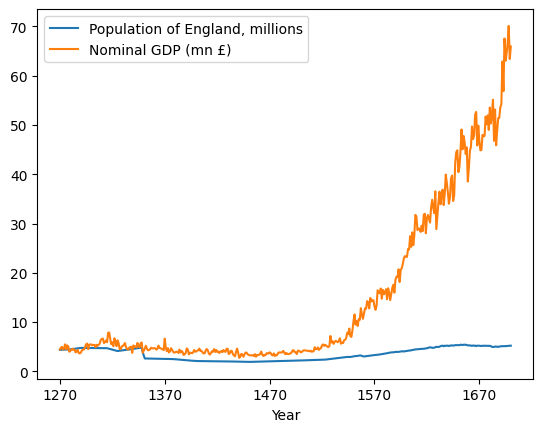

In [38]:
df.plot(x='Year', y=['Population of England, millions', 'Nominal GDP (mn £)'], kind='line')
plt.show()

# Drawing Conclusions

We can see that the population from `1270` to `1700` was comparatively stable, while the GDP from the same time period showed exponential growth.

## Questions for Further Exploration

Were we to continue this exploration, we might delve deeper into the dataset to see if we can determine which sources of GDP were the most relevant for the exponential growth.

Outside of this dataset, we might also explore questions about:
- How other countries' GDP changed during the same time period
- How language or education changed over the same time period